In [1]:
words = open("names.txt","r").read().splitlines()

In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:


print(min(words, key=len))


an


In [5]:
print(max(words, key=len), end = " "); print(len(max(words, key=len)))

muhammadibrahim 15


In [6]:
b  = {}
for w in words:
    chs = ["<S>"] + list(w) + ["<E>"]
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1
        

In [7]:
print(list(b.items()))


[(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 1826), (('n',

In [8]:
sorted(b.items(),key=lambda kv:-kv [1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [9]:
import torch

In [10]:
a = torch.zeros((3,5),dtype = torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [11]:
a.dtype

torch.int32

In [12]:
N = torch.zeros((27,27)) # 26 characters + 1 special token



In [13]:
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
itox = {i+1:s for i,s in enumerate(chars)}
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [14]:
stoi["."]= 0
itox[0]="."


In [15]:
itox

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [16]:

for w in words:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
        

In [17]:
N

tensor([[0.0000e+00, 4.4100e+03, 1.3060e+03, 1.5420e+03, 1.6900e+03, 1.5310e+03,
         4.1700e+02, 6.6900e+02, 8.7400e+02, 5.9100e+02, 2.4220e+03, 2.9630e+03,
         1.5720e+03, 2.5380e+03, 1.1460e+03, 3.9400e+02, 5.1500e+02, 9.2000e+01,
         1.6390e+03, 2.0550e+03, 1.3080e+03, 7.8000e+01, 3.7600e+02, 3.0700e+02,
         1.3400e+02, 5.3500e+02, 9.2900e+02],
        [6.6400e+03, 5.5600e+02, 5.4100e+02, 4.7000e+02, 1.0420e+03, 6.9200e+02,
         1.3400e+02, 1.6800e+02, 2.3320e+03, 1.6500e+03, 1.7500e+02, 5.6800e+02,
         2.5280e+03, 1.6340e+03, 5.4380e+03, 6.3000e+01, 8.2000e+01, 6.0000e+01,
         3.2640e+03, 1.1180e+03, 6.8700e+02, 3.8100e+02, 8.3400e+02, 1.6100e+02,
         1.8200e+02, 2.0500e+03, 4.3500e+02],
        [1.1400e+02, 3.2100e+02, 3.8000e+01, 1.0000e+00, 6.5000e+01, 6.5500e+02,
         0.0000e+00, 0.0000e+00, 4.1000e+01, 2.1700e+02, 1.0000e+00, 0.0000e+00,
         1.0300e+02, 0.0000e+00, 4.0000e+00, 1.0500e+02, 0.0000e+00, 0.0000e+00,
         8.4200e+

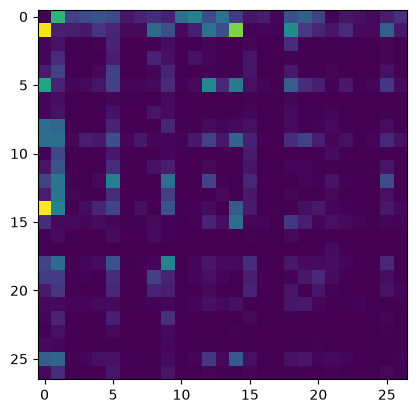

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [19]:
N[3,3].item()

42.0

In [20]:
N[0].sum()


tensor(32033.)

In [21]:
p = N[0]/N[0].float().sum().item()

In [22]:
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [23]:
p.sum()

tensor(1.)

In [24]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix
itox[ix]

'c'

In [25]:
sampledwords = []

In [26]:
ix = 0
sampledwords = []
for _ in range (1,10):
    tempword = ""
    while True:
        
        p = N[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        tempword += itox[ix]
        if ix == 0:
            sampledwords.append(tempword)
            break
sampledwords

['exze.',
 'momasurailezitynn.',
 'konimittain.',
 'llayn.',
 'ka.',
 'da.',
 'staiyaubrtthrigotai.',
 'moliellavo.',
 'ke.']

In [27]:
torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([22, 14,  4, 18, 22, 19, 18, 12, 14, 14, 26, 12, 24, 12, 18, 14, 18,  0,
         1, 14])

In [32]:
P = (N+1).float()
P = P/P.sum(1, keepdim=True)


In [33]:
log_likelihood = 0.0
n = 0

#for w in words:
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
log_likelihood=tensor(-27.8672)
nll=tensor(27.8672)
3.4834020137786865


In [34]:
log_likelihood = 0.0
n = 0

#for w in words:
for w in ["andrej"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
j.: 0.0246 -3.7051
log_likelihood=tensor(-21.2574)
nll=tensor(21.2574)
3.036771774291992


In [35]:
xs,ys = [], []
for w in words[:1]:
    chs = ["."] + list(w) + ["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
        
        

In [36]:
xs,ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

In [39]:
import torch.nn.functional as F 

xenc = F.one_hot(xs,num_classes=27).float()


In [42]:
W = torch.randn((27,27))
xenc @ W

tensor([[ 8.2091e-01,  5.9150e-01,  1.8270e+00, -1.1265e-01, -1.6687e+00,
          1.2620e+00,  9.9472e-01, -1.5429e+00, -1.4360e+00, -8.9522e-01,
         -2.8939e-01,  1.8289e-01,  4.7346e-01, -1.0171e+00,  6.4475e-01,
         -4.1809e-01, -1.8717e-01, -2.3389e-01,  2.1336e+00, -1.1197e+00,
          1.1381e+00,  7.1954e-02,  1.0890e+00, -1.4178e+00, -3.7783e-01,
         -9.8867e-01, -4.3286e-01],
        [-1.8391e-03, -2.9267e-01, -9.4061e-02, -2.4972e-01, -3.1499e-01,
         -1.7608e+00, -5.2987e-01, -2.1532e-01,  1.9100e-01,  1.3430e+00,
          1.0793e+00,  2.7445e+00, -7.0069e-01,  1.7072e+00, -1.6618e-02,
         -7.9780e-01,  3.2626e-01,  1.2033e+00,  1.0811e+00, -8.5498e-01,
          6.1868e-01, -1.0810e+00,  1.2195e-01,  1.8403e+00, -2.0522e+00,
          9.3100e-01, -1.5931e+00],
        [ 2.7779e-01,  9.3344e-01, -1.0782e+00, -1.5607e+00, -1.5535e+00,
         -6.9999e-01, -1.0803e+00,  6.5521e-01,  9.2261e-01,  1.4078e+00,
         -4.2740e-01, -2.0925e-01,  2.05

In [ ]:
xenc = F.one_hot(xs,num_classes=27).float()
logits = (xenc @ W)
counts = logits.exp()
probs = counts/counts.sum(1,keepdim=True)
probs


tensor([18, 11, 12, 12, 24])